# Tipos de datos en visualización científica exploratoria
**Clase 3 — Campos vectoriales 2D**

**Programación Científica 2026-1 · Universidad Nacional de Colombia**  
mbastidaso@unal.edu.co

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)
---

- Representación con `quiver` (flechas)
- Representación con `streamplot` (líneas de flujo)
- Combinaciones y codificación de magnitud

---
## 0. Importaciones y configuración global

In [1]:
#!sudo apt-get update
#!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

#!pip install colorspacious

import matplotlib.pyplot as plt

import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

import numpy as np

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 14,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid                          # ← bug 1: sintaxis mezclada
    "grid.color"    : "gray",       # todo debe ir como claves del dict
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Configuración OK


---
# 1. Campos vectoriales 2D

Un **campo vectorial** asigna un vector $(u, v)$ a cada punto $(x, y)$ del dominio:
$$\mathbf{F}(x, y) = u(x,y)\,\hat{\mathbf{x}} + v(x,y)\,\hat{\mathbf{y}}$$

Aparece en:
- **Mecánica de fluidos**: velocidad del viento, corrientes oceánicas
- **Electromagnetismo**: campo eléctrico $\mathbf{E}$, campo magnético $\mathbf{B}$
- **Gradientes**: $\nabla f$ de cualquier campo escalar

Las dos representaciones principales son `quiver` (flechas en cada punto de la grilla) y `streamplot` (líneas de flujo continuas).

In [2]:
# ── Malla para campos vectoriales ───────────────────────────────────────
# Dos resoluciones:
#   - N_q (gruesa): para quiver — demasiadas flechas satura la figura
#   - N_s (fina):  para streamplot — necesita resolución para trazar las líneas

N_q = 20    # 20×20 = 400 flechas — ya es denso
N_s = 200   # 200×200 para streamplot

x_q = np.linspace(-2, 2, N_q)
y_q = np.linspace(-2, 2, N_q)
Xq, Yq = np.meshgrid(x_q, y_q)

x_s = np.linspace(-2, 2, N_s)
y_s = np.linspace(-2, 2, N_s)
Xs, Ys = np.meshgrid(x_s, y_s)


def campo_rotacional(X, Y):
    """F = (-y, x): rotación pura alrededor del origen.
    Toda partícula orbita en círculos. Vorticidad máxima."""
    U = -Y
    V =  X
    return U, V


def campo_dipolo(X, Y, eps=0.05):
    """Gradiente del potencial de dos cargas ±1 en (±1, 0).
    La carga + es fuente (líneas salen), la − es sumidero (líneas entran).
    eps: radio mínimo para evitar la singularidad en las cargas."""
    # Distancias a cada carga
    r1 = np.sqrt((X + 1)**2 + Y**2)
    r2 = np.sqrt((X - 1)**2 + Y**2)
    r1 = np.where(r1 < eps, eps, r1)  # evitar división por cero
    r2 = np.where(r2 < eps, eps, r2)
    # Componentes del campo eléctrico (gradiente del potencial)
    U = (X + 1) / r1**3 - (X - 1) / r2**3
    V =  Y      / r1**3 -  Y      / r2**3
    return U, V


def campo_silla(X, Y):
    """F = grad(x² − y²) = (2x, −2y).
    El origen es un punto de silla: el campo diverge en x y converge en y.
    Aparece en flujos potenciales y en óptica de aceleradores."""
    U =  2 * X
    V = -2 * Y
    return U, V

print('Campos definidos: rotacional, dipolo, silla de montar.')

Campos definidos: rotacional, dipolo, silla de montar.


# 2 `quiver` — representación con flechas

`quiver(X, Y, U, V)` dibuja una flecha en cada punto `(X[i,j], Y[i,j])` con dirección `(U[i,j], V[i,j])`.

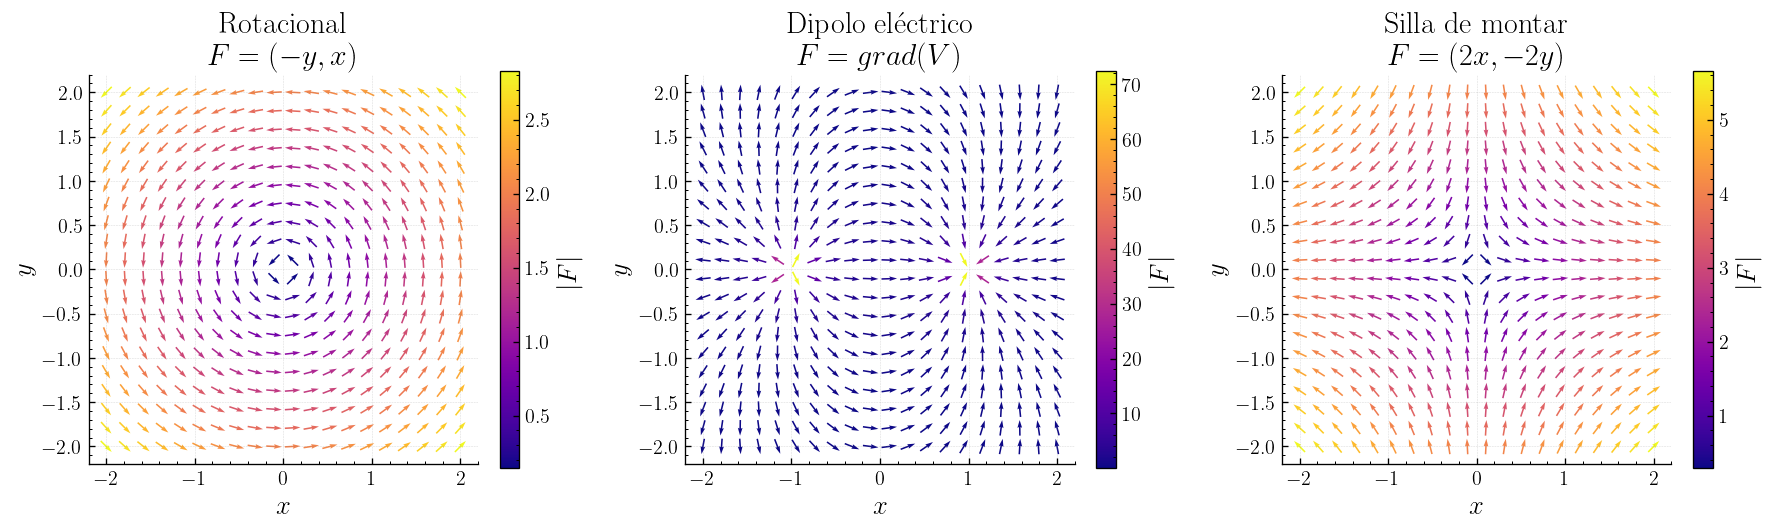

In [3]:
# ── quiver: los tres campos ───────────────────────────────────────────────
campos = [
    ('Rotacional\n$F=(-y, x)$',        campo_rotacional),
    ('Dipolo eléctrico\n$F = grad(V)$', campo_dipolo),
    ('Silla de montar\n$F=(2x,-2y)$',   campo_silla),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
#fig.suptitle('Campos vectoriales 2D — representación con quiver', fontsize=13)

for ax, (titulo, fn) in zip(axes, campos):
    U, V = fn(Xq, Yq)       # componentes en la grilla gruesa
    mag  = np.sqrt(U**2 + V**2)  # magnitud en cada punto

    # Normalización: cada flecha apunta en la dirección correcta
    # pero todas tienen el mismo largo (longitud = 1 antes del escalado de quiver)
    # np.where evita la división por cero donde mag=0
    Un = np.where(mag > 0, U / mag, 0)
    Vn = np.where(mag > 0, V / mag, 0)

    # quiver: dibuja flechas normalizadas coloreadas por magnitud
    # C=mag:    el color de cada flecha codifica la magnitud original
    # cmap:     colormap para la magnitud
    # scale=25: factor de escala global (mayor = flechas más cortas)
    # width:    ancho del eje de la flecha en unidades de la figura
    # pivot='mid': el punto de anclaje está en el centro de la flecha
    qv = ax.quiver(
        Xq, Yq, Un, Vn,
        mag,              # C: color codifica la magnitud
        cmap='plasma',
        scale=25,
        width=0.004,
        pivot='mid',
        lw=1,
    )
    plt.colorbar(qv, ax=ax, label='$|F|$', fraction=0.046)
    ax.set_title(titulo)
    ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
    ax.set_aspect('equal')
    ax.grid(True)

plt.tight_layout()
plt.show()

### Parámetros clave de `quiver`

| Parámetro | Efecto |
|---|---|
| `scale` | Mayor valor = flechas más cortas. Por defecto es automático pero suele ser demasiado grande o pequeño |
| `width` | Ancho del eje de la flecha. Valores típicos: 0.003–0.006 |
| `pivot` | Punto de anclaje: `'tail'` (por defecto), `'mid'`, `'tip'` |
| `C` (arg posicional) | Array de valores → controla el color de cada flecha |
| `headwidth` | Ancho de la cabeza de la flecha (en múltiplos de `width`) |
| `headlength` | Largo de la cabeza de la flecha |

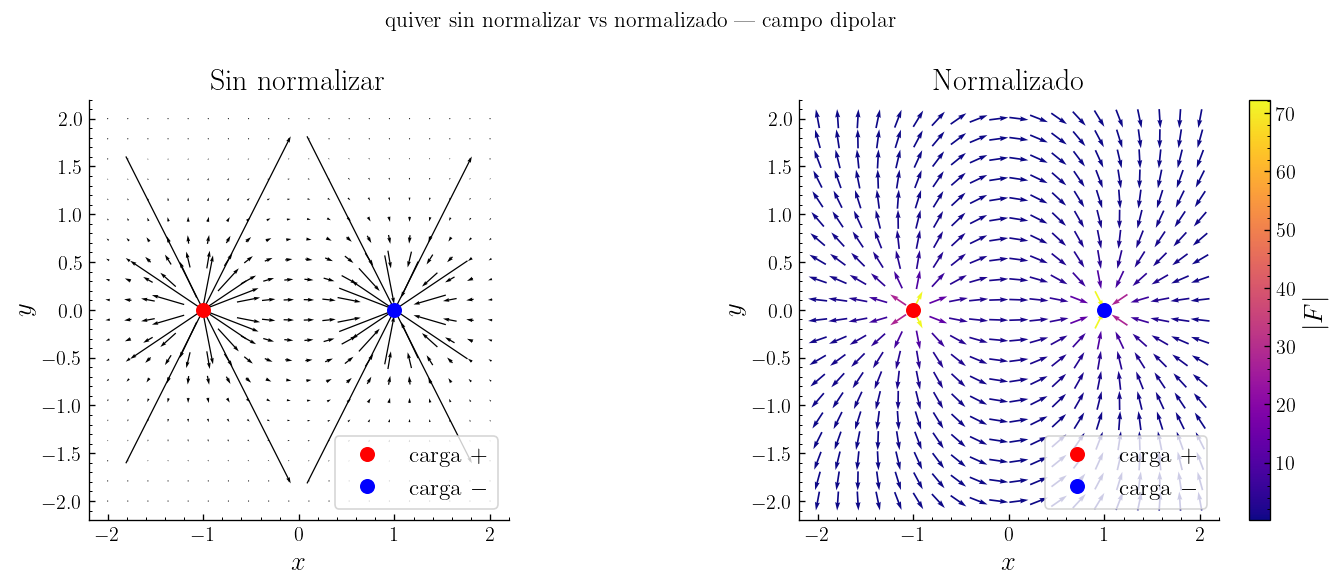

In [4]:
# ── quiver sin normalizar vs normalizado — comparación ───────────────────
# El dipolo es el ejemplo más dramático porque la magnitud varía varios órdenes
U_d, V_d = campo_dipolo(Xq, Yq)
mag_d = np.sqrt(U_d**2 + V_d**2)
Un_d = np.where(mag_d > 0, U_d / mag_d, 0)
Vn_d = np.where(mag_d > 0, V_d / mag_d, 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('quiver sin normalizar vs normalizado — campo dipolar', fontsize=13)

# Sin normalizar: las flechas cerca de las cargas dominan completamente
# Las flechas lejos son invisibles
axes[0].quiver(Xq, Yq, U_d, V_d, pivot='mid')
axes[0].set_title('Sin normalizar')
axes[0].set_xlabel('$x$'); axes[0].set_ylabel('$y$')
axes[0].set_aspect('equal')

# Normalizado + color = magnitud: se ven la dirección en todo el dominio
# y la magnitud queda codificada en el color
qv2 = axes[1].quiver(
    Xq, Yq, Un_d, Vn_d,
    mag_d,
    cmap='plasma',
    scale=22, width=0.004, pivot='mid',
)

axes[1].set_title('Normalizado')
axes[1].set_xlabel('$x$'); axes[1].set_ylabel('$y$')
axes[1].set_aspect('equal')
plt.colorbar(qv2, ax=axes[1], label='$|F|$', fraction=0.046)

# Marcar las posiciones de las cargas
for ax in axes:
    ax.plot(-1, 0, 'o', color='red',  ms=8, zorder=5, label='carga +')
    ax.plot( 1, 0, 'o', color='blue', ms=8, zorder=5, label='carga −')
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

# 3 `streamplot` — líneas de flujo

`streamplot(X, Y, U, V)` traza líneas que son tangentes al campo vectorial en cada punto — las **líneas de flujo** o **líneas de campo**.

Son más legibles que `quiver` para mostrar la estructura global del campo, pero no muestran flechas discretas: **no se puede leer la magnitud puntual** directamente.

La magnitud se puede codificar en:
- `color`: el color de cada línea de flujo
- `linewidth`: el grosor de la línea

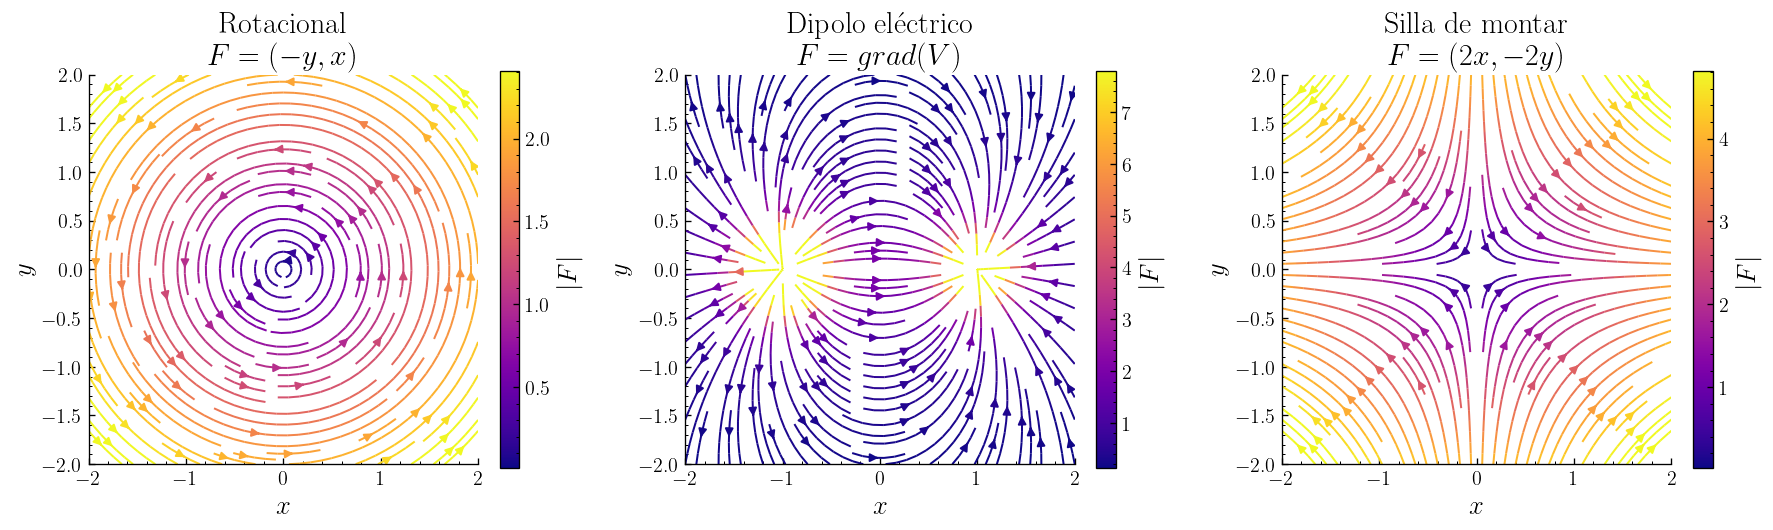

In [5]:
# ── streamplot: los tres campos ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
#fig.suptitle('Campos vectoriales 2D — representación con streamplot', fontsize=13)

for ax, (titulo, fn) in zip(axes, campos):
    # streamplot necesita la grilla FINA para trazar líneas suaves
    U, V = fn(Xs, Ys)
    mag  = np.sqrt(U**2 + V**2)

    # Recortamos la magnitud para que el colormap no quede dominado
    # por los valores extremos cerca de las singularidades
    mag_clip = np.clip(mag, 0, np.percentile(mag, 95))

    # streamplot:
    # color=mag_clip: el color de cada línea codifica la magnitud local
    # linewidth=...:  el grosor también puede codificar la magnitud
    # density:        número de líneas por unidad de área (default=1)
    #                 mayor = más líneas, más denso
    # arrowsize:      tamaño de las flechitas a lo largo de la línea
    sp = ax.streamplot(
        Xs, Ys, U, V,
        color=mag_clip,
        cmap='plasma',
        linewidth=1.2,
        density=1.2,
        arrowsize=1.0,
    )
    plt.colorbar(sp.lines, ax=ax, label='$|F|$', fraction=0.046)
    ax.set_title(titulo)
    ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
    ax.set_aspect('equal')
    ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)

plt.tight_layout()
plt.show()

### Parámetros clave de `streamplot`

| Parámetro | Efecto |
|---|---|
| `color` | Array 2D o string → color de cada línea. Puede ser la magnitud, la vorticidad, etc. |
| `linewidth` | Escalar o array 2D → puede codificar la magnitud en el grosor |
| `density` | Densidad de líneas de flujo. Default=1. Mayor = más líneas |
| `arrowsize` | Tamaño de las flechitas a lo largo de la línea |
| `start_points` | Array (N,2) con puntos de inicio específicos para las líneas |

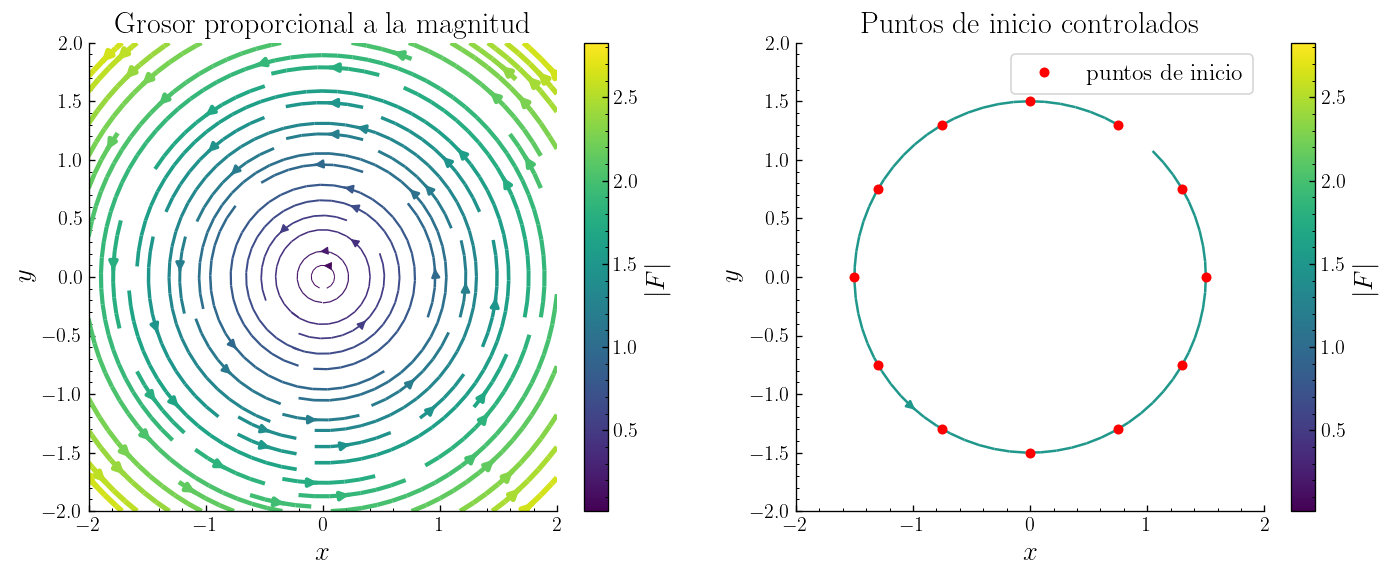

In [6]:
# ── streamplot con grosor variable + puntos de inicio controlados ─────────
U_r, V_r = campo_rotacional(Xs, Ys) # campo_dipolo
mag_r = np.sqrt(U_r**2 + V_r**2)

# Puntos de inicio distribuidos en un círculo
# Permite controlar exactamente desde dónde salen las líneas
theta_start = np.linspace(0, 2*np.pi, 12, endpoint=False)
r_start = 1.5   # radio del círculo de inicio
start_points = np.column_stack([
    r_start * np.cos(theta_start),
    r_start * np.sin(theta_start),
])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#fig.suptitle('streamplot — grosor variable y puntos de inicio', fontsize=13)

# Panel 1: grosor codifica la magnitud
# lw proporcional a la magnitud: donde el campo es más fuerte, la línea es más gruesa
lw = 0.5 + 3.0 * mag_r / mag_r.max()  # rango [0.5, 3.5]
sp1 = axes[0].streamplot(
    Xs, Ys, U_r, V_r,
    color=mag_r, cmap='viridis',
    linewidth=lw,
    density=1.0,
)
plt.colorbar(sp1.lines, ax=axes[0], label='$|F|$', fraction=0.046)
axes[0].set_title('Grosor proporcional a la magnitud')
axes[0].set_xlabel('$x$'); axes[0].set_ylabel('$y$')
axes[0].set_aspect('equal')
axes[0].set_xlim(-2, 2); axes[0].set_ylim(-2, 2)

# Panel 2: puntos de inicio controlados
sp2 = axes[1].streamplot(
    Xs, Ys, U_r, V_r,
    color=mag_r, cmap='viridis',
    linewidth=1.5,
    start_points=start_points,  # líneas salen exactamente de estos puntos
)
# Marcar los puntos de inicio
axes[1].plot(start_points[:, 0], start_points[:, 1],
             'o', color='red', ms=5, zorder=5, label='puntos de inicio')
plt.colorbar(sp2.lines, ax=axes[1], label='$|F|$', fraction=0.046)
axes[1].set_title('Puntos de inicio controlados')
axes[1].set_xlabel('$x$'); axes[1].set_ylabel('$y$')
axes[1].set_aspect('equal')
axes[1].set_xlim(-2, 2); axes[1].set_ylim(-2, 2)
axes[1].legend()

plt.tight_layout()
plt.show()

## 1.4 Comparación: `quiver` vs `streamplot`

| | `quiver` | `streamplot` |
|---|---|---|
| **Muestra** | Vectores discretos en puntos de la grilla | Líneas continuas tangentes al campo |
| **Magnitud** | En el largo de la flecha o en el color | En el color o en el grosor de la línea |
| **Estructura global** | Difícil de leer con muchas flechas | Excelente: las líneas muestran la topología |
| **Detalle local** | Bueno: valor puntual explícito | Limitado: interpolado |
| **Singularidades** | Problemático sin normalizar | Robusto (maneja densidad automáticamente) |
| **Uso típico** | Campos suaves, pocos vectores, física cuantitativa | Fluidos, EM, análisis cualitativo de la estructura |

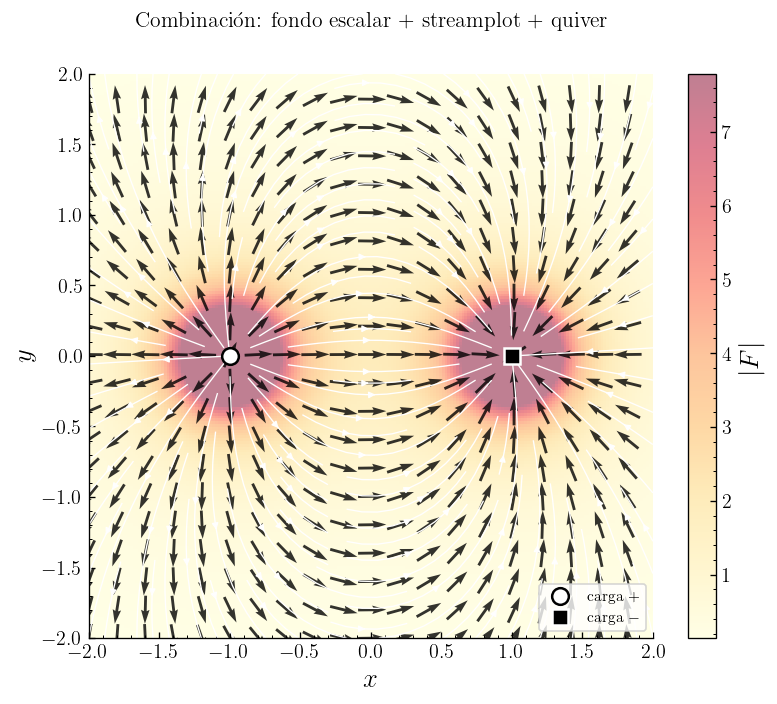

In [7]:
# ── Combinación: streamplot + quiver submuestra + campo escalar de fondo ──
# Esta figura combina las tres herramientas para mostrar todo a la vez:
#   - fondo: campo escalar (magnitud) con pcolormesh
#   - encima: streamplot para la estructura global
#   - encima: quiver submuestreado para los vectores discretos

U_d, V_d = campo_dipolo(Xs, Ys)
mag_d_s  = np.sqrt(U_d**2 + V_d**2)
mag_clip = np.clip(mag_d_s, 0, np.percentile(mag_d_s, 95))

# Grilla submuestreada para quiver (1 de cada 10 puntos)
step = 10
Xsub = Xs[::step, ::step]; Ysub = Ys[::step, ::step]
Usub, Vsub = campo_dipolo(Xsub, Ysub)
mag_sub = np.sqrt(Usub**2 + Vsub**2)
Usub_n = np.where(mag_sub > 0, Usub/mag_sub, 0)
Vsub_n = np.where(mag_sub > 0, Vsub/mag_sub, 0)

fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle('Combinación: fondo escalar + streamplot + quiver', fontsize=13)

# Capa 1: magnitud del campo como imagen de fondo
pc = ax.pcolormesh(Xs, Ys, mag_clip, cmap='YlOrRd', shading='auto', alpha=0.5)
plt.colorbar(pc, ax=ax, label='$|F|$', fraction=0.046)

# Capa 2: streamplot con líneas blancas semitransparentes
ax.streamplot(
    Xs, Ys, U_d, V_d,
    color='white', linewidth=0.8,
    density=1.2, arrowsize=0.8,
)

# Capa 3: quiver submuestreado, negro, para los vectores discretos
ax.quiver(
    Xsub, Ysub, Usub_n, Vsub_n,
    color='black', scale=20, width=0.005,
    pivot='mid', alpha=0.8,
)

# Marcar las cargas
ax.plot(-1, 0, 'o', color='white', ms=10, zorder=10,
        markeredgecolor='black', markeredgewidth=1.5, label='carga +')
ax.plot( 1, 0, 's', color='black', ms=10, zorder=10,
        markeredgecolor='white', markeredgewidth=1.5, label='carga −')

ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_aspect('equal')
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

# 5 Gradiente de un campo escalar

El gradiente $\nabla f$ es el campo vectorial más común en ciencias: apunta en la dirección de máximo crecimiento de $f$ y su magnitud es la tasa de cambio.

`np.gradient` calcula el gradiente numéricamente mediante diferencias finitas centradas.

In [ ]:
import numpy as np

# ── Gradiente numérico de un campo escalar ────────────────────────────────
N_g = 150
x_g = np.linspace(-3, 3, N_g)
y_g = np.linspace(-3, 3, N_g)
Xg, Yg = np.meshgrid(x_g, y_g)

# Campo escalar: función peaks
Zg = (  3*(1 - Xg)**2 * np.exp(-Xg**2 - (Yg + 1)**2)
      - 10*(Xg/5 - Xg**3 - Yg**5) * np.exp(-Xg**2 - Yg**2)
      - 1/3 * np.exp(-(Xg + 1)**2 - Yg**2) )

# np.gradient: diferencias finitas centradas
# Devuelve [∂Z/∂y, ∂Z/∂x] (orden de ejes de la grilla)
# x_g[1]-x_g[0]: tamaño de paso para normalizar las diferencias
dx = x_g[1] - x_g[0]
dZdy, dZdx = np.gradient(Zg, dx, dx)
# El gradiente ∇Z = (∂Z/∂x, ∂Z/∂y) apunta en la dirección de máximo crecimiento

mag_g = np.sqrt(dZdx**2 + dZdy**2)  # magnitud del gradiente

# Submuestreo para quiver
step_g = 8
Xqs = Xg[::step_g, ::step_g]; Yqs = Yg[::step_g, ::step_g]
dZdx_s = dZdx[::step_g, ::step_g]; dZdy_s = dZdy[::step_g, ::step_g]
mag_gs  = mag_g[::step_g, ::step_g]
# Normalizar para quiver
Un_g = np.where(mag_gs > 0, dZdx_s/mag_gs, 0)
Vn_g = np.where(mag_gs > 0, dZdy_s/mag_gs, 0)


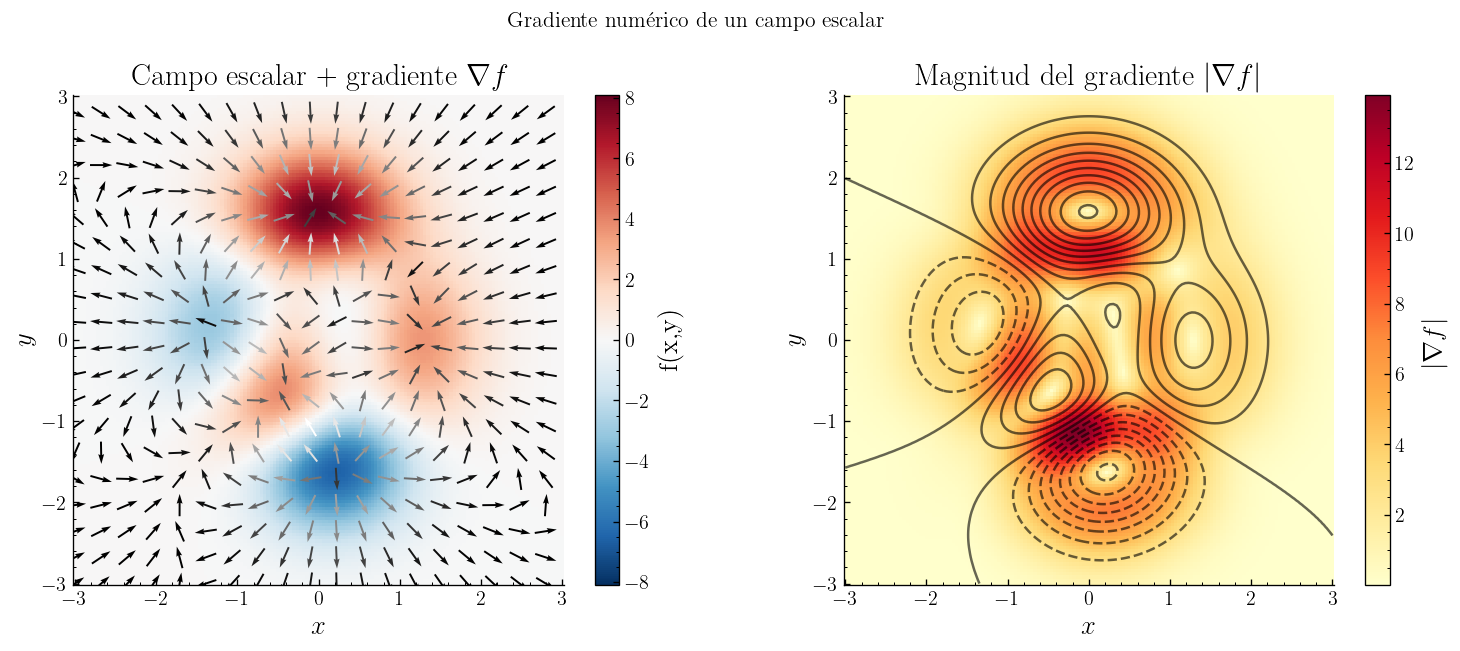

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Gradiente numérico de un campo escalar', fontsize=13)

# Panel 1: campo escalar + quiver del gradiente
vlim_g = max(abs(Zg.min()), abs(Zg.max()))
pc_g = axes[0].pcolormesh(Xg, Yg, Zg, cmap='RdBu_r',
                           vmin=-vlim_g, vmax=vlim_g, shading='auto', alpha=1)
axes[0].quiver(
    Xqs, Yqs, Un_g, Vn_g,
    mag_gs, cmap='Greys_r',
    scale=22, width=0.004, pivot='mid',
)
axes[0].set_title('Campo escalar + gradiente $\\nabla f$')
axes[0].set_xlabel('$x$'); axes[0].set_ylabel('$y$')
axes[0].set_aspect('equal')
plt.colorbar(pc_g, ax=axes[0], label='f(x,y)', fraction=0.046)

# Panel 2: magnitud del gradiente (cuánto cambia el campo en cada punto)
# Los bordes de los extremos tienen gradiente alto → contornos del campo
pm_g = axes[1].pcolormesh(Xg, Yg, mag_g, cmap='YlOrRd', shading='auto')
axes[1].contour(Xg, Yg, Zg, levels=20, colors='k', linewidths=1.5, alpha=0.6)
axes[1].set_title('Magnitud del gradiente $|\\nabla f|$')
axes[1].set_xlabel('$x$'); axes[1].set_ylabel('$y$')
axes[1].set_aspect('equal')
plt.colorbar(pm_g, ax=axes[1], label='$|\\nabla f|$', fraction=0.046)

plt.tight_layout()

plt.show()